# Task 0 — NLP

## (1) Cosine Similarity Between Two Images

In [1]:
from PIL import Image
import numpy as np


def image_to_gray_array(path: str) -> np.ndarray:
    """Load an image with Pillow, convert to grayscale, then to a numpy array."""
    img = Image.open(path).convert("L")  # L = grayscale
    return np.asarray(img, dtype=np.float64)


def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Cosine similarity between two arrays (same spatial crop, then flattened)."""
    h = min(a.shape[0], b.shape[0])
    w = min(a.shape[1], b.shape[1])
    a_flat = a[:h, :w].flatten()
    b_flat = b[:h, :w].flatten()

    dot = np.dot(a_flat, b_flat)
    norm_a = np.linalg.norm(a_flat)
    norm_b = np.linalg.norm(b_flat)

    if norm_a == 0 or norm_b == 0:
        return 0.0

    return float(dot / (norm_a * norm_b))


img1_path = "desert.jpg"
img2_path = "forest.jpg"

arr1 = image_to_gray_array(img1_path)
arr2 = image_to_gray_array(img2_path)

print("Image 1 shape:", arr1.shape)
print("Image 2 shape:", arr2.shape)
print("Cosine similarity:", cosine_similarity(arr1, arr2))

Image 1 shape: (1040, 1920)
Image 2 shape: (819, 1334)
Cosine similarity: 0.8946244040413521


## (2) Signal Plots with Matplotlib & NumPy

1. **Damped cosine**
2. **Linear chirp** (frequency sweeping from f = 3 Hz to f = 10 Hz)

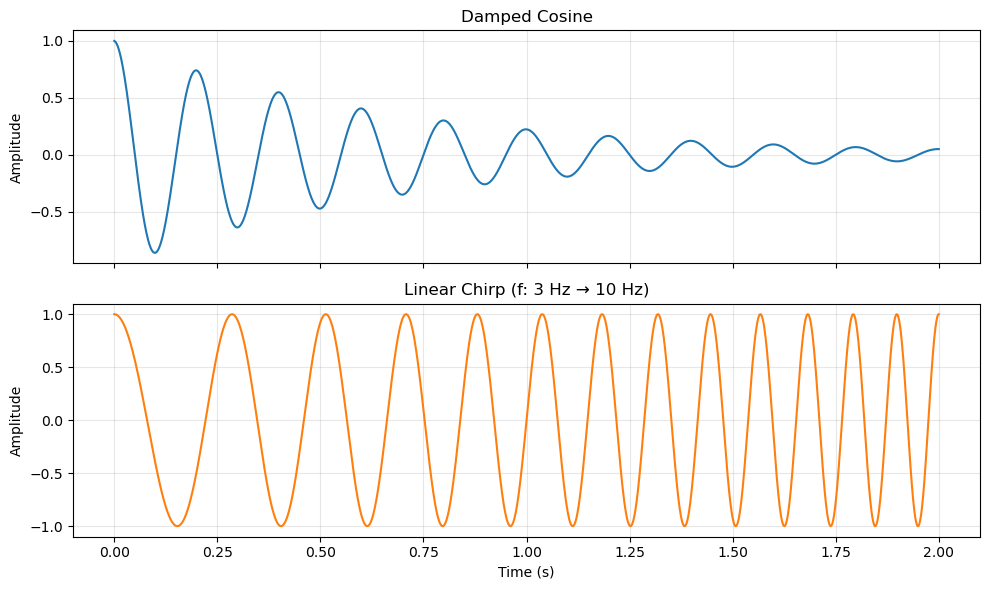

In [2]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 2, 2000)  # 2 seconds

# ---- 1) Damped cosine: e^(-αt) * cos(2π f t) ----
alpha = 1.5
f_damped = 5
damped = np.exp(-alpha * t) * np.cos(2 * np.pi * f_damped * t)

# ---- 2) Linear chirp: frequency from f=3 to f=10 ----
f0, f1 = 3, 10
T = t[-1]
# Instantaneous frequency: f(t) = f0 + (f1 - f0) * t / T
# Phase = 2π ∫ f(τ) dτ = 2π (f0 t + (f1-f0) t² / (2T))
chirp = np.cos(2 * np.pi * (f0 * t + (f1 - f0) * t**2 / (2 * T)))

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t, damped, color="C0")
axes[0].set_title("Damped Cosine")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, chirp, color="C1")
axes[1].set_title("Linear Chirp (f: 3 Hz → 10 Hz)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()